# Exploratory Data Analysis (EDA) – Loan Prediction Dataset

## Objective
The goal of this analysis is to understand the structure, distribution, and relationships within the loan dataset before building a machine learning model.

This includes:
- Dataset overview
- Missing value analysis
- Target variable analysis
- Statistical summary
- Correlation analysis

In [ ]:
#Install Kaggle
!pip install kaggle --quiet

## Upload Kaggle API Key

Upload the `kaggle.json` file from your Kaggle account.
This file allows the notebook to download datasets directly from Kaggle.

In [ ]:
#Upload Kaggle.Json File
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"goundlalasya","key":"1a12b9c89193bd9c150e6802b9637de2"}'}

## Configure Kaggle Credentials

The API key must be placed in the `.kaggle` directory with proper permissions so Kaggle commands can access datasets securely.

In [ ]:
!mkdir -p ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

## Download Dataset

We download the Loan Prediction dataset from Kaggle and extract the files.

In [ ]:
!kaggle datasets download -d hossamhibrahem/loan-prediction-analytics-vidhya

Dataset URL: https://www.kaggle.com/datasets/hossamhibrahem/loan-prediction-analytics-vidhya
License(s): unknown
  0% 0.00/13.6k [00:00<?, ?B/s]
100% 13.6k/13.6k [00:00<00:00, 50.2MB/s]


In [ ]:
!unzip loan-prediction-analytics-vidhya.zip

Archive:  loan-prediction-analytics-vidhya.zip
  inflating: sample_submission_49d68Cx.csv  
  inflating: test_lAUu6dG.csv        
  inflating: train_ctrUa4K.csv       


## Import Required Libraries

We use the following libraries:

- **Pandas** → Data manipulation
- **Matplotlib** → Basic visualization
- **Seaborn** → Statistical visualization

In [ ]:
!ls

kaggle.json			      sample_submission_49d68Cx.csv
loan-prediction-analytics-vidhya.zip  test_lAUu6dG.csv
sample_data			      train_ctrUa4K.csv


In [ ]:
import pandas as pd
df=pd.read_csv("train_ctrUa4K.csv")

## Load Dataset

We load the dataset using pandas.

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Dataset Shape

This shows the number of rows and columns in the dataset.

In [ ]:
df.shape

(614, 13)

## Dataset Information

This command provides:
- column names
- data types
- number of non-null values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Missing Value Analysis

Real-world datasets often contain missing values.  
We check how many missing values exist in each column.

In [ ]:
df.isnull()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,False,False,False,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,False,False,False,False,False,False,False,False,False,False,False,False,False
610,False,False,False,False,False,False,False,False,False,False,False,False,False
611,False,False,False,False,False,False,False,False,False,False,False,False,False
612,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


## Target Variable Analysis

Loan_Status is the target variable indicating whether the loan was approved or rejected.

In [ ]:
df["Loan_Status"]

,Loan_Status
0,Y
1,N
2,Y
3,Y
4,Y
...,...
609,Y
610,Y
611,Y
612,Y


In [ ]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


## Loan Status Distribution

We visualize how many loans were approved and rejected.

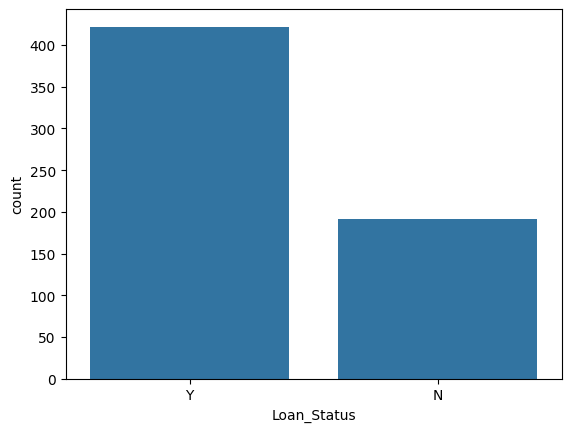

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x="Loan_Status",data=df)
plt.show()

## Correlation Heatmap

Correlation helps understand relationships between numerical variables in the dataset.

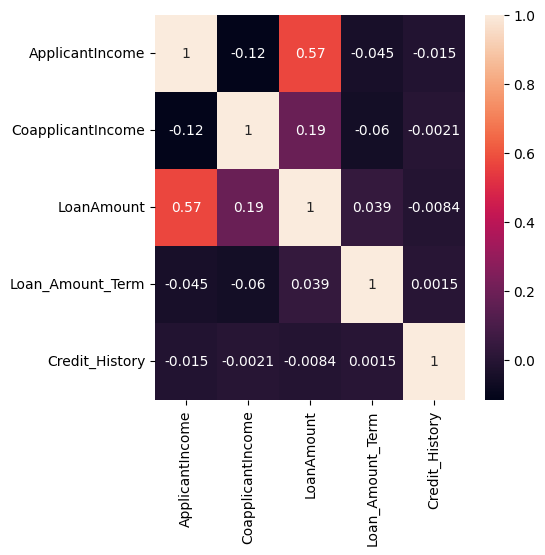

In [ ]:
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## Key Observations

- The dataset contains missing values in multiple columns.
- Loan approval distribution can be observed using count plots.
- Correlation heatmaps help understand relationships between numerical features.

